In [1]:
import pandas as pd

# Дані
data = {
    'Outlook':  ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':     ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play':     ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}
df = pd.DataFrame(data)

total = len(df)
yes = len(df[df['Play'] == 'Yes'])  # 9
no  = len(df[df['Play'] == 'No'])   # 5

P_yes = yes / total
P_no  = no  / total

# Умови для передбачення
outlook  = 'Sunny'
humidity = 'Normal'
wind     = 'Strong'

# P(ознака | Yes) і P(ознака | No)
p_outlook_yes  = len(df[(df['Outlook']  == outlook)  & (df['Play'] == 'Yes')]) / yes
p_humidity_yes = len(df[(df['Humidity'] == humidity) & (df['Play'] == 'Yes')]) / yes
p_wind_yes     = len(df[(df['Wind']     == wind)     & (df['Play'] == 'Yes')]) / yes

p_outlook_no   = len(df[(df['Outlook']  == outlook)  & (df['Play'] == 'No')]) / no
p_humidity_no  = len(df[(df['Humidity'] == humidity) & (df['Play'] == 'No')]) / no
p_wind_no      = len(df[(df['Wind']     == wind)     & (df['Play'] == 'No')]) / no

# Наївний Баєс
score_yes = p_outlook_yes * p_humidity_yes * p_wind_yes * P_yes
score_no  = p_outlook_no  * p_humidity_no  * p_wind_no  * P_no

# Нормалізація
p_yes_norm = score_yes / (score_yes + score_no)
p_no_norm  = score_no  / (score_yes + score_no)

print(f"Outlook={outlook}, Humidity={humidity}, Wind={wind}")
print()
print(f"P(Yes) = {p_outlook_yes:.4f} * {p_humidity_yes:.4f} * {p_wind_yes:.4f} * {P_yes:.4f} = {score_yes:.4f}")
print(f"P(No)  = {p_outlook_no:.4f} * {p_humidity_no:.4f} * {p_wind_no:.4f} * {P_no:.4f} = {score_no:.4f}")
print()
print(f"Після нормалізації:")
print(f"P(Yes) = {p_yes_norm:.4f} ({p_yes_norm*100:.1f}%)")
print(f"P(No)  = {p_no_norm:.4f} ({p_no_norm*100:.1f}%)")
print()
if p_yes_norm > p_no_norm:
    print("Прогноз: гра відбудеться")
else:
    print("Прогноз: гра не відбудеться")

Outlook=Sunny, Humidity=Normal, Wind=Strong

P(Yes) = 0.2222 * 0.6667 * 0.3333 * 0.6429 = 0.0317
P(No)  = 0.6000 * 0.2000 * 0.6000 * 0.3571 = 0.0257

Після нормалізації:
P(Yes) = 0.5525 (55.2%)
P(No)  = 0.4475 (44.8%)

Прогноз: гра відбудеться


Медіана ціни: 60.30 €
Дешевих квитків: 11436
Дорогих квитків: 11280

Точність моделі: 70.7%


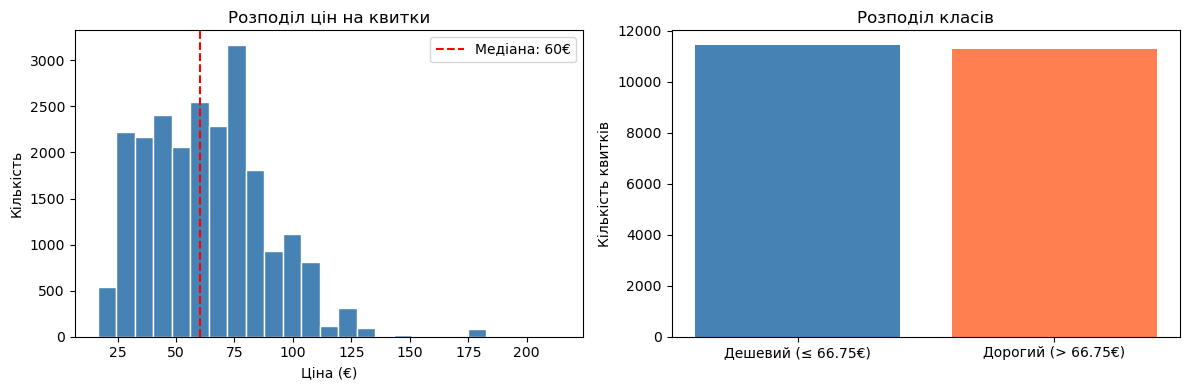

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Завантаження даних
df = pd.read_csv('https://raw.githubusercontent.com/susanli2016/Machine-Learning-with-Python/master/data/renfe_small.csv')

# Видаляємо рядки без ціни
df = df.dropna(subset=['price'])

# Цільова змінна: дорогий квиток чи ні (вище медіани = дорогий)
median_price = df['price'].median()
df['expensive'] = (df['price'] > median_price).astype(int)

print(f"Медіана ціни: {median_price:.2f} €")
print(f"Дешевих квитків: {(df['expensive'] == 0).sum()}")
print(f"Дорогих квитків: {(df['expensive'] == 1).sum()}")

#кодуємо категоріальні ознаки в числа
le = LabelEncoder()
for col in ['origin', 'destination', 'train_type', 'train_class', 'fare']:
    df[col] = le.fit_transform(df[col].fillna('Unknown'))

#ознаки і мітки
X = df[['origin', 'destination', 'train_type', 'train_class', 'fare']]
y = df['expensive']

#поділ на тренувальну і тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#еавчання моделі
model = GaussianNB()
model.fit(X_train, y_train)

#оцінка
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nТочність моделі: {acc*100:.1f}%")

#графіки
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#розподіл цін
axes[0].hist(df['price'], bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(median_price, color='red', linestyle='--', label=f'Медіана: {median_price:.0f}€')
axes[0].set_title('Розподіл цін на квитки')
axes[0].set_xlabel('Ціна (€)')
axes[0].set_ylabel('Кількість')
axes[0].legend()

#кількість дешевих і дорогих
axes[1].bar(['Дешевий (≤ 66.75€)', 'Дорогий (> 66.75€)'],
            [( df['expensive'] == 0).sum(), (df['expensive'] == 1).sum()],
            color=['steelblue', 'coral'])
axes[1].set_title('Розподіл класів')
axes[1].set_ylabel('Кількість квитків')

plt.tight_layout()
plt.savefig('renfe_bayes.png', dpi=150, bbox_inches='tight')
plt.show()